In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
from tqdm import tqdm
import torchvision
import matplotlib.pyplot as plt

# record start time
_START_RUNTIME = time.time()

# set seed
seed = 24
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
os.environ["PYTHONHASHSEED"] = str(seed)

In [2]:
pwd

'/Users/soheilgolara/Downloads/Project'

In [3]:
ls -l

total 46184632
-rw-r--r--@ 1 soheilgolara  staff       312031 Mar 24 19:35 CNN-1.ipynb
drwxr-xr-x@ 8 soheilgolara  staff          256 Mar 22 13:20 Data/
drwx------@ 5 soheilgolara  staff          160 Mar 24 16:49 Report/
-rw-r--r--@ 1 soheilgolara  staff   2186111965 Mar 20 14:41 balanced_train.pt
-rw-r--r--@ 1 soheilgolara  staff  16693262205 Mar 23 14:54 balanced_train_0p2.pt
-rw-r--r--@ 1 soheilgolara  staff    547636493 Mar 20 14:40 balanced_val.pt
-rw-r--r--@ 1 soheilgolara  staff   4174424045 Mar 23 14:54 balanced_val_0p2.pt
-rw-r--r--@ 1 soheilgolara  staff     44770488 Mar 20 14:39 resnet18_weights_9.pth


In [4]:
def get_cnn_model():

    """
    TODO: Define the CNN model here.
        We will use a ResNet18 model.
        For now, please set `pretrained=False`. We will manually load the weights later.
        Then, replace the last layer (model.fc) with a nn.Linear layer
            The new model.fc should have the same input size but a new output_size of 2
    """

    from torchvision import models

    num_classes = 2
    # your code here
    #raise NotImplementedError
    model = models.resnet18(pretrained=False)
    model.fc = nn.Linear(model.fc.in_features,num_classes)

    #For computation efficiency, we will freeze the weights in the bottom layers
    # for param in model.named_parameters():
    #     if param[0].split(".")[0] == 'fc':
    #         continue
    #     param[1].requires_grad = False
    for name, param in model.named_parameters():
        if "fc" not in name:
            param.requires_grad = False
    return model

In [5]:
assert issubclass(type(get_cnn_model()), nn.Module), "Your CNN model should be a torch.nn.Module instance"
model = get_cnn_model()
assert len(list(model.modules())) == 68, "# of modules mismtach - Please use ResNet18"
assert len(list(model.parameters())) == 62, "# of parameter tensors mismtach - different model. Please use ResNet18"
print("len(list(model.parameters())) ",len(list(model.parameters())) ) #  Returns 62, which is the count of distinct parameter objects/tensors in the list.
print("len(list(model.modules())) ", len(list(model.modules())) )
print("total param",sum(p.numel() for p in model.parameters())) # ResNet-18 has approximately 11.7 million total individual parameters

/Users/soheilgolara/soheil_env/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/soheilgolara/soheil_env/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


len(list(model.parameters()))  62
len(list(model.modules()))  68
total param 11177538


In [6]:
# Count individual weight/bias 'tensors' (layers)
trainable_layers = len([p for p in model.parameters() if p.requires_grad])
frozen_layers = len([p for p in model.parameters() if not p.requires_grad])

# Count total individual parameters (numbers)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)

print(f"Frozen: {frozen_layers} layers ({frozen_params:,} parameters)")
print(f"Trainable: {trainable_layers} layers ({trainable_params:,} parameters)")

Frozen: 60 layers (11,176,512 parameters)
Trainable: 2 layers (1,026 parameters)


In [7]:
print(f"{'Layer Name':<60} | {'Type':<10} | {'Parameters':<12}")
print("-" * 85)

for name, param in model.named_parameters():
    status = "Trainable" if param.requires_grad else "Frozen"
    num_params = param.numel()
    print(f"{name:<60} | {status:<10} | {num_params:>12,}")

# --- Your existing summary logic ---
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)

print("-" * 85)
print(f"Total Frozen Parameters:    {frozen_params:,}")
print(f"Total Trainable Parameters: {trainable_params:,}")

Layer Name                                                   | Type       | Parameters  
-------------------------------------------------------------------------------------
conv1.weight                                                 | Frozen     |        9,408
bn1.weight                                                   | Frozen     |           64
bn1.bias                                                     | Frozen     |           64
layer1.0.conv1.weight                                        | Frozen     |       36,864
layer1.0.bn1.weight                                          | Frozen     |           64
layer1.0.bn1.bias                                            | Frozen     |           64
layer1.0.conv2.weight                                        | Frozen     |       36,864
layer1.0.bn2.weight                                          | Frozen     |           64
layer1.0.bn2.bias                                            | Frozen     |           64
layer1.1.conv1.weight   

In [8]:
model = get_cnn_model()
WEIGHT_PATH='/Users/soheilgolara/Downloads/Project/resnet18_weights_9.pth'
#Load the pretrained weights
#If it fails, it probably means you did not define the model correctly
model.load_state_dict(torch.load(WEIGHT_PATH, map_location='cpu'))

<All keys matched successfully>

In [9]:
# Assuming 'model' is your trained CNN model and 'optimizer' is your optimizer
def save_checkpoint(epoch, model, optimizer, loss, path):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }, path)

def load_checkpoint(checkpoint_path, model, optimizer):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint['epoch']
    loss = checkpoint['loss']
    return model, optimizer, epoch, loss

# Example usage during training:
# save_checkpoint(EPOCH_NUM, model, optimizer, LOSS_VALUE, 'cnn_checkpoint.pt')

In [10]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # your code here
        #raise NotImplementedError
        # (224, 224) --> (3, 248, 496)
        self.conv1=nn.Conv2d(3,8,3) # (8, 246, 494)
        self.conv2=nn.Conv2d(in_channels=8,out_channels=6,kernel_size=2) # 	(6, 245, 493)
        self.conv3=nn.Conv2d(in_channels=6,out_channels=3,kernel_size=3) # 	(3, 243, 491)
        self.pool3=nn.MaxPool2d(2,2) # (3, 121, 245)
        self.fc1=nn.Linear(88935 , 10)
        self.fc2=nn.Linear(10, 2)

    # def forward(self, x):
    #     #input is of shape (batch_size=32, 3, 224, 224) if you did the dataloader right
    #     # your code here
    #     return self.fc2(
    #           F.relu(self.fc1(
    #               torch.flatten(
    #           self.conv3(self.conv2(self.conv1(x)))
    #           ,1))))
    def forward(self, x):
        x = F.leaky_relu(self.conv1(x))
        x = F.leaky_relu(self.conv2(x))
        x = F.leaky_relu(self.conv3(x))
        
        # Flatten: (batch_size, 3*243*491)
        x = self.pool3(x)
        x = torch.flatten(x, 1)
        
        x = F.leaky_relu(self.fc1(x))
        x = self.fc2(x)
        
        # dim=1 applies softmax across the 2 classes for each sample
        return x#F.softmax(x, dim=1) 

#

In [11]:
simple_model = SimpleCNN()
simple_model_size = sum([param.nelement() * param.element_size() for param in simple_model.parameters()]) / 1e9
print('SimpleCNN size in GB:', simple_model_size)
assert simple_model_size <= 1, 'SimpleCNN is too large! Please minimize the number of parameters.'

SimpleCNN size in GB: 0.003559876


In [12]:
# Count individual weight/bias 'tensors' (layers)
print("--- Parameter Counts per Layer/Stage ---")
for name, param in simple_model.named_parameters():
    if param.requires_grad:
        print(f"* Trainable Layer: {name:<50} | Parameters: {param.numel():,}")
    else:
        print(f"* Frozen Layer:    {name:<50} | Parameters: {param.numel():,}")

print("\n--- Total Summary ---")
# Count total layers
trainable_layers = len([p for p in simple_model.parameters() if p.requires_grad])
frozen_layers = len([p for p in simple_model.parameters() if not p.requires_grad])

# Count total individual parameters (numbers)
trainable_params = sum(p.numel() for p in simple_model.parameters() if p.requires_grad)
frozen_params = sum(p.numel() for p in simple_model.parameters() if not p.requires_grad)

print(f"Frozen:    {frozen_layers} layers ({frozen_params:,} parameters)")
print(f"Trainable: {trainable_layers} layers ({trainable_params:,} parameters)")
print(f"Total:     {frozen_layers + trainable_layers} layers ({frozen_params + trainable_params:,} parameters)")

--- Parameter Counts per Layer/Stage ---
* Trainable Layer: conv1.weight                                       | Parameters: 216
* Trainable Layer: conv1.bias                                         | Parameters: 8
* Trainable Layer: conv2.weight                                       | Parameters: 192
* Trainable Layer: conv2.bias                                         | Parameters: 6
* Trainable Layer: conv3.weight                                       | Parameters: 162
* Trainable Layer: conv3.bias                                         | Parameters: 3
* Trainable Layer: fc1.weight                                         | Parameters: 889,350
* Trainable Layer: fc1.bias                                           | Parameters: 10
* Trainable Layer: fc2.weight                                         | Parameters: 20
* Trainable Layer: fc2.bias                                           | Parameters: 2

--- Total Summary ---
Frozen:    0 layers (0 parameters)
Trainable: 10 layers (889,9

In [13]:
if torch.backends.mps.is_available():
      device = torch.device("mps")
elif torch.cuda.is_available():
      device = torch.device("cuda")
else:
      device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


In [30]:
"""
TODO: Specify loss function (CrossEntropyLoss) and assign it to `criterion`.
Spcify optimizer (SGD) and assign it to `optimizer`.
Hint: the learning rate is usually a small number on the scale of 1e-4 ~ 1e-2
"""
weights = torch.tensor([1.0, 50.0]).to(device) 


resnet_criterion = nn.CrossEntropyLoss(weight=weights)
#optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# The "Best Practice" way to skip frozen parameters:
resnet_optimizer = torch.optim.SGD(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

#weights = torch.tensor([1.0, 10.0]).to(device) 
simple_criterion = nn.CrossEntropyLoss(weight=weights)
#optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# imbalanced data
# weights = torch.tensor([1.0, 5.0]).to(device) 
# criterion = nn.CrossEntropyLoss(weight=weights)

# The "Best Practice" way to skip frozen parameters:
simple_optimizer = torch.optim.SGD(
    filter(lambda p: p.requires_grad, simple_model.parameters()),
    lr=0.001)

In [15]:
#

In [16]:
def eval_model(model, dataloader, device):
      model.eval()                                                                                                                          
      Y_pred, Y_true, Y_scores = [], [], []
      for data, target in dataloader:
          data = data.to(device)
          target = target.to(device)
          Y_float = model(data)
          probs = torch.nn.functional.softmax(Y_float, dim=1)  # ← probabilities
          Y_scores.append(probs.detach().cpu().numpy())
          Y_pred.append(torch.nn.functional.one_hot(torch.argmax(Y_float, dim=1), num_classes=2).detach().cpu().numpy())
          Y_true.append(torch.nn.functional.one_hot(target, num_classes=2).detach().cpu().numpy())
      return np.concatenate(Y_pred, axis=0), np.concatenate(Y_true, axis=0), np.concatenate(Y_scores, axis=0)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve  

In [17]:
import torch.optim as optim
import pandas as pd
from sklearn.metrics import accuracy_score

# number of epochs to train the model
# make sure your model finish training within 4 minutes on a CPU machine
# You can experiment different numbers for n_epochs, but even 1 epoch should be good enough.
def train_model(model, train_dataloader, val_dataloader, n_epoch, optimizer, criterion, checkpoint_path, file_name_csv, device):
    """
    :param model: A CNN model
    :param train_dataloader: the DataLoader of the training data
    :param n_epoch: number of epochs to train
    :return:
        model: trained model
    """
##### load prev state
    # 1. Calculate the save frequency (10% of total batches)
    total_batches = len(train_dataloader)
    save_every = max(1, total_batches // 20)

    # --- Load Checkpoint Logic ---
    start_epoch = 0
    if os.path.exists(checkpoint_path):
        print(f"Found checkpoint at {checkpoint_path}. Loading...")
        # Add weights_only=False to allow loading older checkpoints
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint.get('epoch', -1) + 1
        print(f"Resuming from epoch {start_epoch}")
    else:
        print("No checkpoint found. Starting from scratch.")

####
    model.train() # prep model for training

    loss_train = []
    loss_val = []
    f1_val = []
    for epoch in range(n_epoch):
        curr_epoch_loss = []

        #for data, target in tqdm(train_dataloader):
        # enumerate gives us 'batch_idx' to track progress
        for batch_idx, (data, target) in enumerate(tqdm(train_dataloader)):

            """
            TODO: Within the loop, do the normal training procedures:
                   pass the input through the model
                   pass the output through loss_func to compute the loss (name the variable as *loss*)
                   zero out currently accumulated gradient, use loss.basckward to backprop the gradients, then call optimizer.step
            """
            # your code here
            #raise NotImplementedError
            #### MPS on Mac
            data = data.to(device)       # ← add this
            target = target.to(device)   # ← add this
            ###
            predict=model(data)
            loss=criterion(predict, target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            curr_epoch_loss.append(loss.cpu().data.numpy()) 
            
            

            # # 3. Save every 10% of the data
            # if (batch_idx + 1) % save_every == 0:
            #     avg_loss_so_far = np.mean(curr_epoch_loss)
            #     print(f"\n[Batch {batch_idx+1}/{total_batches}] Saving intermediate checkpoint...")
            #     save_checkpoint(epoch, model, optimizer, avg_loss_so_far, checkpoint_path)


        avg_loss = np.mean(curr_epoch_loss)
        print(f"Epoch {epoch}: curr_epoch_loss={avg_loss}")
        save_checkpoint(epoch, model, optimizer, avg_loss, checkpoint_path)
        #
        loss_train.append(avg_loss)
        y_pred, y_true, y_scores = eval_model(model, val_dataloader, device)
        #####
        
        y_pred_idx  = np.argmax(y_pred, axis=1)
        y_true_idx  = np.argmax(y_true, axis=1)
        y_prob_pos  = y_scores[:, 1]  # probability of positive class

        # print(f"Accuracy:  {accuracy_score(y_true_idx, y_pred_idx):.4f}")
        # print(f"Precision: {precision_score(y_true_idx, y_pred_idx):.4f}")
        # print(f"Recall:    {recall_score(y_true_idx, y_pred_idx):.4f}")
        # print(f"F1 Score:  {:.4f}")
        # print(f"AUC-ROC:   {roc_auc_score(y_true_idx, y_prob_pos):.4f}")
        # print(f"Confusion Matrix:\n{confusion_matrix(y_true_idx, y_pred_idx)}")
        #
        val_loss=accuracy_score(y_pred, y_true)
        loss_val.append(val_loss)
        f1=f1_score(y_true_idx, y_pred_idx)
        f1_val.append(f1)
        print(f"Epoch {epoch}: curr_eval_loss={val_loss}")
        print(f"Epoch {epoch}: curr_eval_f1={f1}")
        print(f"Weight sum: {model.conv1.weight.abs().sum().item():.6f}")

# save to CSV
    filename = file_name_csv

# Create a dictionary from the lists with desired column names
    data = {'Column A': loss_train, 'Column B': loss_val}

# Create a DataFrame
    df = pd.DataFrame(data)

# Save the DataFrame to a CSV file, without the default index
    df.to_csv(filename, index=False)

    print(f"File '{filename}' created successfully using pandas.")
    return model

#

In [18]:
def save_processed_dataset(loader, filename="train_data.pt"):
    all_imgs = []
    all_labels = []
    
    print(f"Packing {len(loader.dataset)} images into {filename}...")
    for imgs, labels in loader:
        all_imgs.append(imgs)
        all_labels.append(labels)
        
    # Stack into giant tensors
    data_dict = {
        'imgs': torch.cat(all_imgs), 
        'labels': torch.cat(all_labels)
    }
    torch.save(data_dict, filename)
    print("Done!")

def load_fast_data(filename):
    data = torch.load(filename)
    dataset = torch.utils.data.TensorDataset(data['imgs'], data['labels'])
    return torch.utils.data.DataLoader(dataset, batch_size=8, shuffle=True)

from torch.utils.data import TensorDataset, DataLoader

def load_from_pt(train_path="balanced_train.pt", val_path="balanced_val.pt"):
    # Load the tensors directly into memory
    train_data = torch.load(train_path)
    val_data = torch.load(val_path)
    
    # Reconstruct the datasets
    train_ds = TensorDataset(train_data['imgs'], train_data['labels'])
    val_ds = TensorDataset(val_data['imgs'], val_data['labels'])
    
    # Create loaders
    train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)
    
    return train_loader, val_loader

In [19]:
train_loader, val_loader = load_from_pt(train_path="balanced_train_0p2.pt", val_path="balanced_val_0p2.pt")

In [20]:
def print_counts(dataset, name):
    # dataset.tensors[1] is the labels tensor
    labels = dataset.tensors[1]
    
    # This returns the unique values and how many times each appears
    classes, counts = torch.unique(labels, return_counts=True)
    
    print(f"--- {name} Dataset ---")
    for cls, count in zip(classes, counts):
        print(f"Class {cls.item()}: {count.item()} images")

# After you define train_ds and val_ds in your loading function:
print_counts(train_loader.dataset, "Train")
print_counts(val_loader.dataset, "Validation")

--- Train Dataset ---
Class 0: 10919 images
Class 1: 390 images
--- Validation Dataset ---
Class 0: 2730 images
Class 1: 98 images


In [21]:
import numpy as np

def get_image_dimensions_stats(dataloader, dataset_name):
    heights = []
    widths = []
    channels = []
    batch_size = []
    for images, _ in dataloader:
        # Images tensor shape: (batch_size, channels, height, width)
        b = images.shape[0]
        c = images.shape[1]
        h = images.shape[2]
        w = images.shape[3]
        heights.append(h)
        widths.append(w)
        channels.append(c)
        batch_size.append(b)

    # All images from the same dataloader should have the same dimensions 
    # if no transforms like RandomResizedCrop are used, or if they are, 
    # it will show the output dimension after those transforms.
    min_h = np.min(heights)
    max_h = np.max(heights)
    avg_h = np.mean(heights)

    min_w = np.min(widths)
    max_w = np.max(widths)
    avg_w = np.mean(widths)

    min_c = np.min(channels)
    max_c = np.max(channels)
    avg_c = np.mean(channels)

    print(f"\n--- {dataset_name} Image Dimensions ---")
    print(f"Height: Min={min_h}, Max={max_h}, Avg={avg_h:.2f}")
    print(f"Width:  Min={min_w}, Max={max_w}, Avg={avg_w:.2f}")
    print(f"channels:  Min={min_c}, Max={max_c}, Avg={avg_c:.2f}")

In [22]:
# Get dimensions for training data
#get_image_dimensions_stats(train_loader, "Training")

# Get dimensions for validation data
#get_image_dimensions_stats(val_loader, "Validation")

In [23]:
#

In [24]:
model = model.to('mps')
simple_model=simple_model.to('mps')

In [26]:
seed = 24
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
n_epoch=20                                               

model = train_model(model, train_loader, val_loader, optimizer=resnet_optimizer, n_epoch=n_epoch,
                    criterion=resnet_criterion, checkpoint_path='resnet_model_checkpoint.pt', file_name_csv="resnet.csv"
                    ,device=device)

python(62915) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


No checkpoint found. Starting from scratch.


100%|██████████| 1414/1414 [01:43<00:00, 13.66it/s]


Epoch 0: curr_epoch_loss=0.4103860557079315
Epoch 0: curr_eval_loss=0.9565063649222065
Epoch 0: curr_eval_f1=0.5099601593625498
Weight sum: 716.638916


100%|██████████| 1414/1414 [02:02<00:00, 11.52it/s]


...

Epoch 17: curr_epoch_loss=0.08379451185464859
Epoch 17: curr_eval_loss=0.9759547383309759
Epoch 17: curr_eval_f1=0.7301587301587301
Weight sum: 716.638916


100%|██████████| 1414/1414 [01:20<00:00, 17.52it/s]


Epoch 18: curr_epoch_loss=0.08009248971939087
Epoch 18: curr_eval_loss=0.9840876944837341
Epoch 18: curr_eval_f1=0.8
Weight sum: 716.638916


100%|██████████| 1414/1414 [01:23<00:00, 17.04it/s]


Epoch 19: curr_epoch_loss=0.08031473308801651
Epoch 19: curr_eval_loss=0.963932107496464
Epoch 19: curr_eval_f1=0.6506849315068494
Weight sum: 716.638916
File 'resnet.csv' created successfully using pandas.


In [31]:
n_epoch=20
simple_model = train_model(simple_model, train_loader, val_loader, optimizer=simple_optimizer, n_epoch=n_epoch,
                           criterion=simple_criterion, checkpoint_path='simple_model_checkpoint.pt', file_name_csv="simple.csv"
                           ,device=device)

No checkpoint found. Starting from scratch.


100%|██████████| 1414/1414 [00:52<00:00, 27.04it/s]


Epoch 0: curr_epoch_loss=0.5268345475196838
Epoch 0: curr_eval_loss=0.9653465346534653
Epoch 0: curr_eval_f1=0.0
Weight sum: 21.242790


100%|██████████| 1414/1414 [01:07<00:00, 20.96it/s]


Epoch 1: curr_epoch_loss=0.5288236737251282
Epoch 1: curr_eval_loss=0.9653465346534653
Epoch 1: curr_eval_f1=0.0
Weight sum: 21.235737


...

Epoch 17: curr_epoch_loss=0.0002010288881137967
Epoch 17: curr_eval_loss=0.9992927864214993
Epoch 17: curr_eval_f1=0.9897959183673469
Weight sum: 22.104853


100%|██████████| 1414/1414 [00:50<00:00, 28.02it/s]


Epoch 18: curr_epoch_loss=0.00017244844639208168
Epoch 18: curr_eval_loss=0.9996463932107497
Epoch 18: curr_eval_f1=0.9948717948717949
Weight sum: 22.111687


100%|██████████| 1414/1414 [01:02<00:00, 22.78it/s]


Epoch 19: curr_epoch_loss=0.0001492856245022267
Epoch 19: curr_eval_loss=0.9996463932107497
Epoch 19: curr_eval_f1=0.9948717948717949
Weight sum: 22.117334
File 'simple.csv' created successfully using pandas.


In [32]:
## Load check point
checkpoint_path='resnet_model_checkpoint.pt'
print(f"Found checkpoint at {checkpoint_path}. Loading...")
# Add weights_only=False to allow loading older checkpoints
checkpoint = torch.load(checkpoint_path, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
resnet_optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
start_epoch = checkpoint.get('epoch', -1) + 1
print(f"Resuming from epoch {start_epoch}")

Found checkpoint at resnet_model_checkpoint.pt. Loading...
Resuming from epoch 20


In [33]:
## Load check point
checkpoint_path='simple_model_checkpoint.pt'
print(f"Found checkpoint at {checkpoint_path}. Loading...")
# Add weights_only=False to allow loading older checkpoints
checkpoint = torch.load(checkpoint_path, weights_only=False)
simple_model.load_state_dict(checkpoint['model_state_dict'])
simple_optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
start_epoch = checkpoint.get('epoch', -1) + 1
print(f"Resuming from epoch {start_epoch}")

Found checkpoint at simple_model_checkpoint.pt. Loading...
Resuming from epoch 20


In [34]:
from sklearn.metrics import accuracy_score

# y_pred, y_true = eval_model(model, val_loader, device)
# acc = accuracy_score(y_true, y_pred)
# print(("Validation Accuracy: " + str(acc)))

# print(y_true.shape,y_pred.shape)
# #print("Precision:", precision_score(y_true, y_pred))
# #assert acc > 0.7, "Validation Accuracy below 0.7 for validation data!"
# #assert len(y_true) == len(y_pred) == 151, "Output size is wrong"

In [35]:
#


In [36]:
from sklearn.metrics import precision_recall_curve, auc

In [37]:
def model_sum(model, model_str, val_loader, device):
    y_pred, y_true, y_scores = eval_model(model, val_loader, device)

    # Convert one-hot → class indices for sklearn
    y_pred_idx  = np.argmax(y_pred, axis=1)
    y_true_idx  = np.argmax(y_true, axis=1)
    y_prob_pos  = y_scores[:, 1]  # probability of positive class

    print(f"Accuracy:  {accuracy_score(y_true_idx, y_pred_idx):.4f}")
    print(f"Precision: {precision_score(y_true_idx, y_pred_idx):.4f}")
    print(f"Recall:    {recall_score(y_true_idx, y_pred_idx):.4f}")
    print(f"F1 Score:  {f1_score(y_true_idx, y_pred_idx):.4f}")
    print(f"AUC-ROC:   {roc_auc_score(y_true_idx, y_prob_pos):.4f}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_true_idx, y_pred_idx)}")

    import matplotlib.pyplot as plt                                                                                                           
    from sklearn.metrics import ConfusionMatrixDisplay, roc_curve  
    # --- Confusion Matrix → CSV ---
    cm = confusion_matrix(y_true_idx, y_pred_idx)                                                                                             
    cm_df = pd.DataFrame(cm,
                        index=['Actual Negative', 'Actual Positive'],
                        columns=['Predicted Negative', 'Predicted Positive'])
    cm_df.to_csv(model_str+"confusion_matrix.csv")
    print("Confusion matrix saved to confusion_matrix.csv")

    # --- AUC-ROC Curve → PDF ---
    fpr, tpr, thresholds = roc_curve(y_true_idx, y_prob_pos)
    auc_score = roc_auc_score(y_true_idx, y_prob_pos)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc_score:.4f}')
    ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random classifier')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(model_str+"roc_curve.pdf")
    plt.show()
    print("ROC curve saved to roc_curve.pdf")
    
    # Calculate PR-AUC
    precisions, recalls, _ = precision_recall_curve(y_true_idx, y_prob_pos)
    pr_auc_score = auc(recalls, precisions)
    
    # --- PR Curve → PDF (Added) ---
    plt.figure(figsize=(7, 6))
    plt.plot(recalls, precisions, color='darkorange', lw=2, label=f'PR AUC = {pr_auc_score:.4f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc='lower left')
    plt.grid(True, alpha=0.3)
    plt.savefig(model_str + "pr_curve.pdf")
    plt.show()

    print(f"Files saved: {model_str}confusion_matrix.csv, {model_str}roc_curve.pdf, {model_str}pr_curve.pdf")

Accuracy:  0.9639
Precision: 0.4897
Recall:    0.9694
F1 Score:  0.6507
AUC-ROC:   0.9951
Confusion Matrix:
[[2631   99]
 [   3   95]]
Confusion matrix saved to confusion_matrix.csv


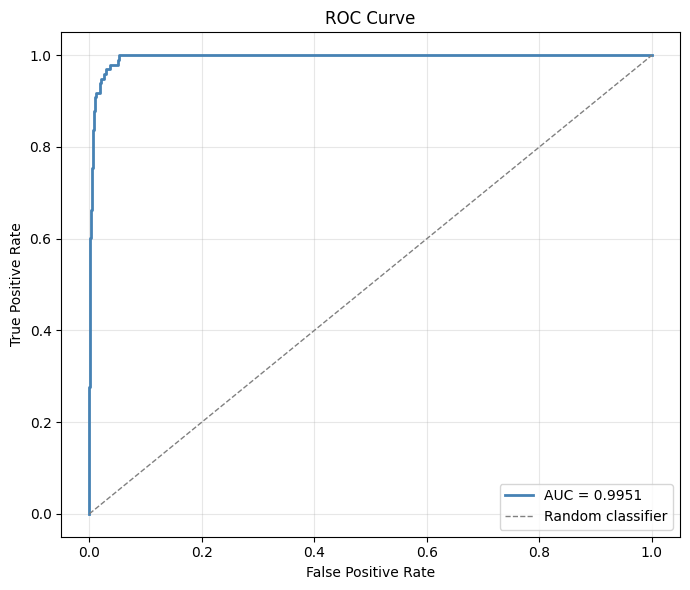

ROC curve saved to roc_curve.pdf


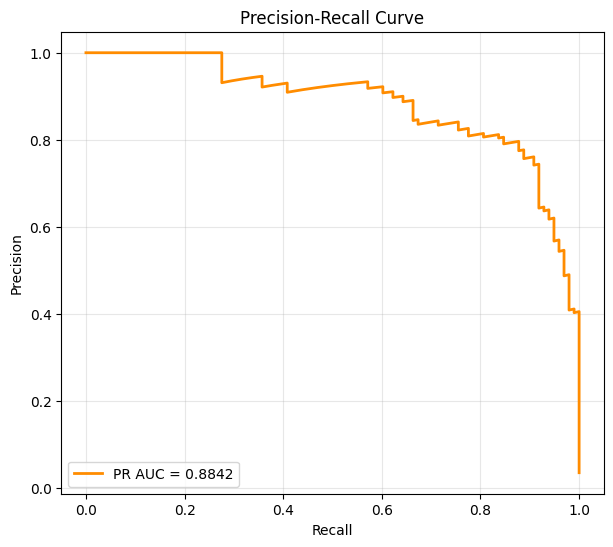

Files saved: resnetconfusion_matrix.csv, resnetroc_curve.pdf, resnetpr_curve.pdf


In [38]:
model_sum(model=model, model_str="resnet", val_loader=val_loader, device=device)

Accuracy:  0.9996
Precision: 1.0000
Recall:    0.9898
F1 Score:  0.9949
AUC-ROC:   1.0000
Confusion Matrix:
[[2730    0]
 [   1   97]]
Confusion matrix saved to confusion_matrix.csv


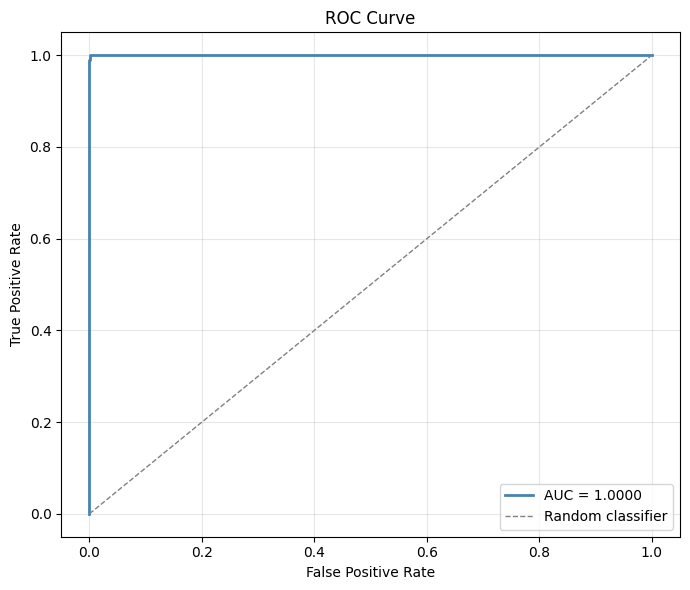

ROC curve saved to roc_curve.pdf


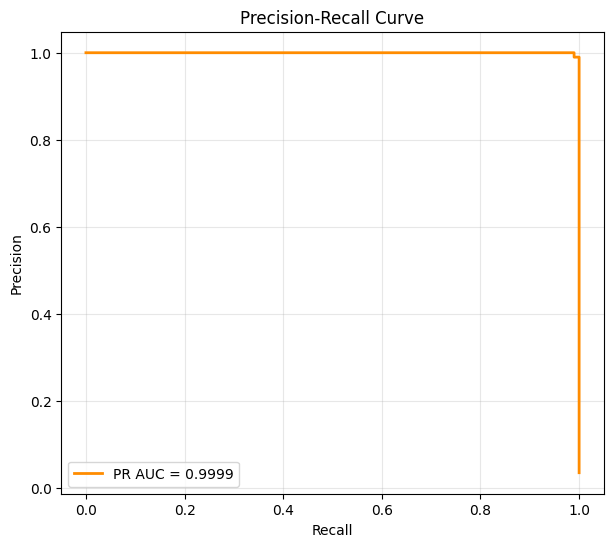

Files saved: this workconfusion_matrix.csv, this workroc_curve.pdf, this workpr_curve.pdf


In [39]:
model_sum(model=simple_model, model_str="this work", val_loader=val_loader, device=device)

In [40]:
def plot_roc_comparison(model1, name1, model2, name2, dataloader, device):
      results = []
      for model, name in [(model1, name1), (model2, name2)]:
          y_pred, y_true, y_scores = eval_model(model, dataloader, device)
          y_true_idx = np.argmax(y_true, axis=1)
          y_prob_pos = y_scores[:, 1]
          fpr, tpr, _ = roc_curve(y_true_idx, y_prob_pos)
          auc_score = roc_auc_score(y_true_idx, y_prob_pos)
          results.append((fpr, tpr, auc_score, name))

      fig, ax = plt.subplots(figsize=(7, 6))
      colors = ['steelblue', 'darkorange']
      for (fpr, tpr, auc_score, name), color in zip(results, colors):
          ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc_score:.4f})')
      ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random classifier')
      ax.set_xlabel('False Positive Rate')
      ax.set_ylabel('True Positive Rate')
      ax.set_title('ROC Curve Comparison')
      ax.legend(loc='lower right')
      ax.grid(True, alpha=0.3)
      plt.tight_layout()
      plt.savefig("roc_curve_comparison.pdf")
      plt.show()

In [41]:
def plot_pr_comparison(model1, name1, model2, name2, dataloader, device):
    results = []
    for model, name in [(model1, name1), (model2, name2)]:
        # Get predictions
        y_pred, y_true, y_scores = eval_model(model, dataloader, device)
        
        # Convert one-hot to class indices (if necessary) and get positive class probs
        y_true_idx = np.argmax(y_true, axis=1) if y_true.ndim > 1 else y_true
        y_prob_pos = y_scores[:, 1]
        
        # Calculate PR metrics
        precisions, recalls, _ = precision_recall_curve(y_true_idx, y_prob_pos)
        pr_auc = auc(recalls, precisions)
        
        results.append((recalls, precisions, pr_auc, name))

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(7, 6))
    colors = ['steelblue', 'darkorange']
    
    for (recalls, precisions, pr_auc, name), color in zip(results, colors):
        ax.plot(recalls, precisions, color=color, lw=2, label=f'{name} (PR-AUC = {pr_auc:.4f})')
    
    # Calculate baseline (ratio of positive class in dataset)
    baseline = np.sum(y_true_idx) / len(y_true_idx)
    ax.axhline(y=baseline, color='gray', lw=1, linestyle='--', label=f'Baseline ({baseline:.2f})')
    
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title('Precision-Recall Curve Comparison')
    ax.legend(loc='lower left')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("pr_comparison.pdf")
    plt.show()
    print("PR comparison plot saved to pr_comparison.pdf")

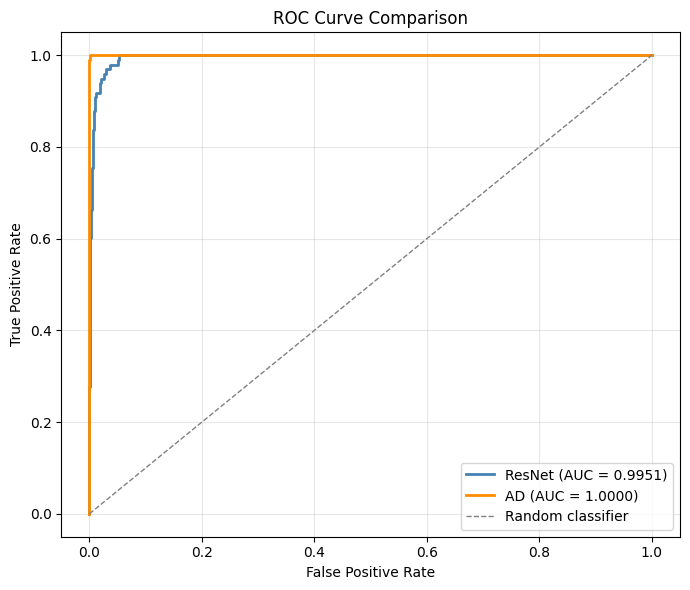

In [43]:
plot_roc_comparison(model, "ResNet", simple_model, "this work", val_loader, device)

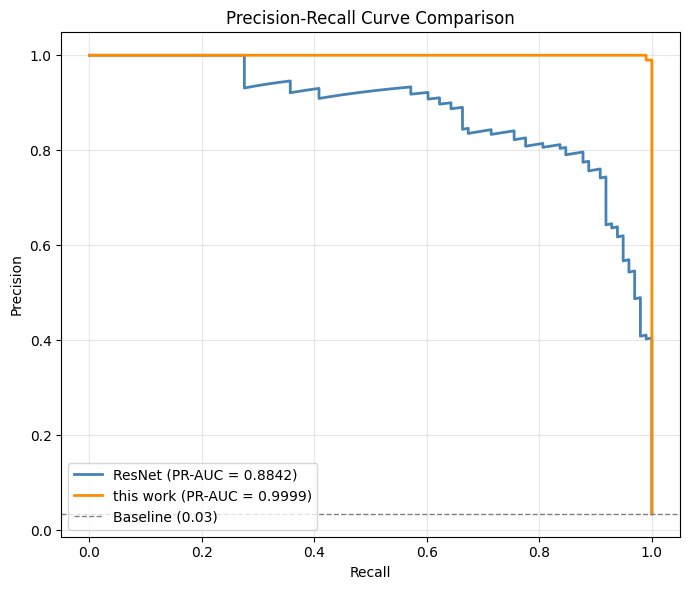

PR comparison plot saved to pr_comparison.pdf


In [42]:
plot_pr_comparison(model, "ResNet", simple_model, "this work", val_loader, device)